In [1]:
from google.colab import userdata
#userdata.get('TU-LLAVE-1');
#userdata.get('TU-URL-DE-SERVICIO');


In [2]:
import json, os, requests


# Clave generada en el portal de Azure
subscription_key = str(userdata.get('TU-LLAVE-1'))


# URL de la aplicación que queremos correr
face_api_url = str(userdata.get('TU-URL-DE-SERVICIO')) + '/face/v1.0/detect'


# URL de una imágen a utilizar
image_url = 'https://github.com/gilecheverria/MNA_data/blob/main/Images/amusement_park.png?raw=true'



image_url = 'https://datagef.blob.core.windows.net/contenedorgilbertoecheverria/amusement_park.png?raw=true'


# Configuración de la clave a utilizar
headers = {'Ocp-Apim-Subscription-Key': subscription_key}


# Parámtros para la solicitud al servicio
params = {
    'returnFaceId': 'false',
    'returnFaceLandmarks': 'true',
    #'returnFaceAttributes': 'age, gender headPose, smile, facialHair, glasses, emotion',
}


# Llamada al servicio
response = requests.post(face_api_url, params=params, headers=headers, json={"url": image_url})
# Almacenar el resultado en formato JSON
faces = response.json()
# Mostrar el resultado como texto
json.dumps(faces)



'[{"faceRectangle": {"top": 352, "left": 467, "width": 50, "height": 50}, "faceLandmarks": {"pupilLeft": {"x": 479.8, "y": 366.1}, "pupilRight": {"x": 503.6, "y": 367.2}, "noseTip": {"x": 493.8, "y": 377.7}, "mouthLeft": {"x": 479.6, "y": 388.1}, "mouthRight": {"x": 500.7, "y": 389.4}, "eyebrowLeftOuter": {"x": 470.8, "y": 361.6}, "eyebrowLeftInner": {"x": 489.6, "y": 361.4}, "eyeLeftOuter": {"x": 477.3, "y": 366.6}, "eyeLeftTop": {"x": 480.2, "y": 365.6}, "eyeLeftBottom": {"x": 480.2, "y": 367.2}, "eyeLeftInner": {"x": 483.0, "y": 366.6}, "eyebrowRightInner": {"x": 497.2, "y": 361.6}, "eyebrowRightOuter": {"x": 513.3, "y": 363.2}, "eyeRightInner": {"x": 500.1, "y": 367.2}, "eyeRightTop": {"x": 503.6, "y": 366.3}, "eyeRightBottom": {"x": 503.7, "y": 367.7}, "eyeRightOuter": {"x": 506.6, "y": 367.4}, "noseRootLeft": {"x": 488.6, "y": 367.0}, "noseRootRight": {"x": 496.0, "y": 367.1}, "noseLeftAlarTop": {"x": 487.1, "y": 374.2}, "noseRightAlarTop": {"x": 497.6, "y": 374.6}, "noseLeftAlar

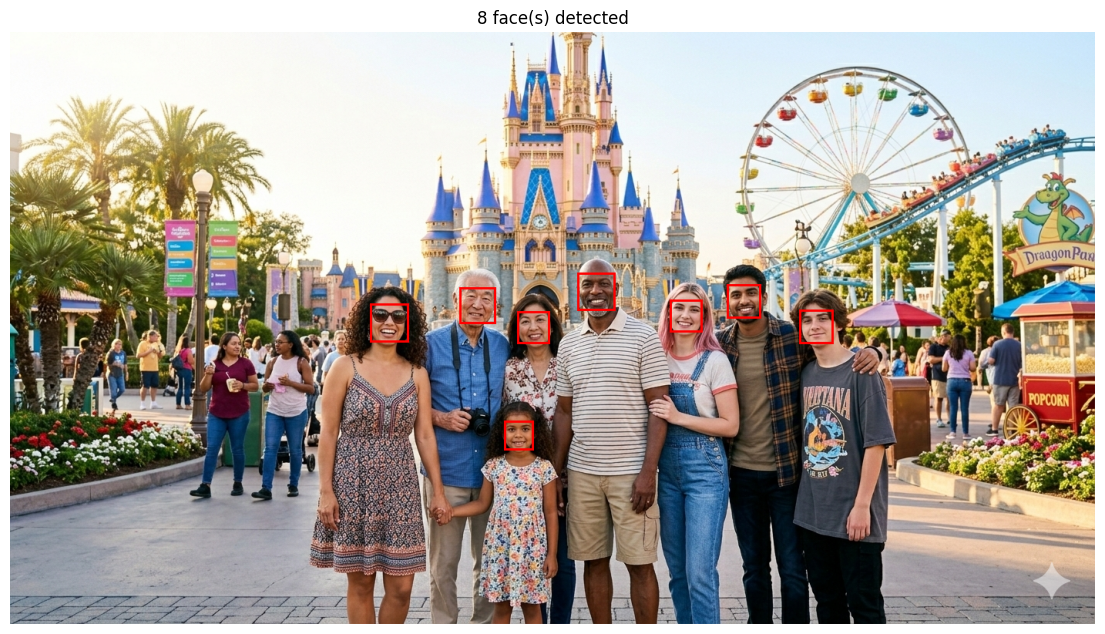

In [3]:
from PIL import Image, ImageDraw
from io import BytesIO
import matplotlib.pyplot as plt

# Descargar los datos de la imagen
img_data = requests.get(image_url)
# Crear un objeto para poder dibujar la foto
img = Image.open(BytesIO(img_data.content))

# Nuevo objeto para poder dibujar figuras sobre la foto
draw = ImageDraw.Draw(img)

# Mostrar un rectángulo alrededor de las caras detectadas
for face in faces:
  rect = face['faceRectangle']
  left = rect['left']
  top = rect['top']
  right = left + rect['width']
  bottom = top + rect['height']

  draw.rectangle([left, top, right, bottom], outline='red', width=3)

# Formateo de la imagen resultante
plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis('off')
plt.title(f"{len(faces)} face(s) detected")
plt.show()

In [4]:
pip install azure-ai-textanalytics azure-core

In [5]:
from google.colab import userdata
#userdata.get('Servicio2_KEY');
#userdata.get('Servicio2_ENDPOINT');

In [6]:
from azure.core.credentials import AzureKeyCredential
from azure.ai.textanalytics import TextAnalyticsClient

# Reemplazar con API keys
key = str(userdata.get('Servicio2_KEY'))
endpoint = str(userdata.get('Servicio2_ENDPOINT'))

# Crear cliente
client = TextAnalyticsClient(
    endpoint=endpoint,
    credential=AzureKeyCredential(key)
)

# Textos de prueba
documents = [
    "Me gustó mucho el servicio, fue rápido y eficiente.",
    "La experiencia fue regular, no estuvo mal pero tampoco excelente.",
    "No me gustó el producto, llegó tarde y en mal estado.",
    "This platform is amazing and very easy to use.",
    "The support was terrible and nobody solved my problem."
]

# Analizar sentimiento
response = client.analyze_sentiment(documents=documents)

for i, doc in enumerate(response):
    print(f"Texto {i+1}: {documents[i]}")
    print(f"Sentimiento: {doc.sentiment}")
    print(f"Positivo: {doc.confidence_scores.positive:.2f}")
    print(f"Neutral: {doc.confidence_scores.neutral:.2f}")
    print(f"Negativo: {doc.confidence_scores.negative:.2f}")
    print("-" * 50)

Texto 1: Me gustó mucho el servicio, fue rápido y eficiente.
Sentimiento: positive
Positivo: 1.00
Neutral: 0.00
Negativo: 0.00
--------------------------------------------------
Texto 2: La experiencia fue regular, no estuvo mal pero tampoco excelente.
Sentimiento: negative
Positivo: 0.03
Neutral: 0.08
Negativo: 0.89
--------------------------------------------------
Texto 3: No me gustó el producto, llegó tarde y en mal estado.
Sentimiento: negative
Positivo: 0.00
Neutral: 0.00
Negativo: 1.00
--------------------------------------------------
Texto 4: This platform is amazing and very easy to use.
Sentimiento: positive
Positivo: 1.00
Neutral: 0.00
Negativo: 0.00
--------------------------------------------------
Texto 5: The support was terrible and nobody solved my problem.
Sentimiento: negative
Positivo: 0.00
Neutral: 0.00
Negativo: 1.00
--------------------------------------------------


In [7]:
pip install feedparser

In [8]:
import random
import re
import feedparser
from bs4 import BeautifulSoup
from azure.core.credentials import AzureKeyCredential
from azure.ai.textanalytics import TextAnalyticsClient

AZURE_KEY = str(userdata.get('Servicio2_KEY'))
AZURE_ENDPOINT = str(userdata.get('Servicio2_ENDPOINT'))

RSS_URL = "https://letterboxd.com/darrencb/rss/"

def clean_html(html_text):
    soup = BeautifulSoup(html_text, "html.parser")
    text = soup.get_text(" ", strip=True)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def looks_like_review(text):
    # Evitar listas, rankings y contenido raro
    banned_phrases = [
        "other film categories",
        "view the full list on letterboxd",
        "plus",
        "more.",
    ]

    lower = text.lower()

    if any(phrase in lower for phrase in banned_phrases):
        return False

    # Debe tener tamaño razonable y parecer opinión
    if len(text) < 40 or len(text) > 1500:
        return False

    return True

def get_random_review_from_rss(rss_url):
    feed = feedparser.parse(rss_url)
    candidates = []

    for entry in feed.entries:
        raw_text = ""

        if "summary" in entry:
            raw_text = entry.summary
        elif "description" in entry:
            raw_text = entry.description

        clean_text = clean_html(raw_text)

        if looks_like_review(clean_text):
            candidates.append(clean_text)

    if not candidates:
        return None

    return random.choice(candidates)

def analyze_sentiment(text):
    client = TextAnalyticsClient(
        endpoint=AZURE_ENDPOINT,
        credential=AzureKeyCredential(AZURE_KEY)
    )

    result = client.analyze_sentiment(documents=[text])[0]

    return {
        "sentiment": result.sentiment,
        "positive": result.confidence_scores.positive,
        "neutral": result.confidence_scores.neutral,
        "negative": result.confidence_scores.negative,
    }

def main():
    review = get_random_review_from_rss(RSS_URL)

    if not review:
        print("No se encontró una reseña válida en el RSS.")
        return

    print("RESEÑA ALEATORIA:\n")
    print(review)
    print("\n" + "-" * 50)

    result = analyze_sentiment(review)

    print("ANÁLISIS DE SENTIMIENTO:")
    print("Sentimiento general:", result["sentiment"])
    print(f"Positivo: {result['positive']:.2f}")
    print(f"Neutral: {result['neutral']:.2f}")
    print(f"Negativo: {result['negative']:.2f}")

if __name__ == "__main__":
    main()

RESEÑA ALEATORIA:

This review may contain spoilers. The Perfect Neighbour is a film designed to make your blood boil. It is infuriating to watch. We see a woman harass a family for years, call the police repeatedly for ridiculously minor disputes, and then eventually shoot a mother dead from inside a locked house. It's a tragic story, filled with entitlement and lies and an undertone of racism. Yet for all the emotional power of The Perfect Neighbour , it does seem a little off. Eventually justice was done and this killer was imprisoned for decades, based on the available evidence. It's a film about an awful event and a community torn apart, but what we see here is not a killer freed or a proven case of premeditated murder. The Perfect Neighbour feels like it was searching for injustice but instead its messaging around the dangers of stand-your-ground laws are somewhat undermined by the eventual imprisonment of the killer. Those laws perhaps emboldened her but the film cannot prove th